In [12]:
#julia -t 4

using Plots
using Random, Statistics, Distributions
using SparseArrays
using LinearAlgebra
using DifferentialEquations
using StatsPlots 

using Statistics 
using Distributions, Random, Plots, StatsBase  
using Base.Threads



include("../Project_with_Jon/GPs.jl")


log_marginal_likelihood (generic function with 1 method)

In [13]:


# -------------------------
# Training Data
# -------------------------


X_train = collect(range(-4, 4, length=20))

y_train = sin.(X_train) .+
          0.2 .* randn(length(X_train)) 

σf = 1.0
σn = 0.2

 
#

0.2

In [14]:

# -------------------------
# GP Hyperparameter tuning
# -------------------------

ℓ_candidates = [0.1, 0.3, 1.0, 3.0, 10.0]

best_ℓ = nothing
best_ll = -Inf

for ℓ_try in ℓ_candidates

    ll = log_marginal_likelihood(X_train, y_train;
                                  ℓ=ℓ_try,
                                  σf=1.0,
                                  σn=0.2)

    println("ℓ = ", ℓ_try, "  logML = ", ll)

    if ll > best_ll
        best_ll = ll
        best_ℓ = ℓ_try
    end
end

println("\nBest ℓ = ", best_ℓ, " (logML = ", best_ll, ")")

ℓ = 0.1  logML = -23.34849448823063
ℓ = 0.3  logML = -20.276721782241918
ℓ = 1.0  logML = -6.137589626915172
ℓ = 3.0  logML = -17.698485796630575
ℓ = 10.0  logML = -106.83361621309486

Best ℓ = 1.0 (logML = -6.137589626915172)


In [17]:
ℓ = best_ℓ
#ℓ = 0.1
σf = 1.0
σn = 0.2

# -------------------------
# Test Points
# -------------------------
X_test = collect(range(-5, 5, length=300))

# -------------------------
# Covariance Matrices
# -------------------------
K =
    kernel_matrix(X_train, X_train;
                  ℓ=ℓ, σf=σf) +
    σn^2 * I

Ks =
    kernel_matrix(X_train, X_test;
                  ℓ=ℓ, σf=σf)

Kss =
    kernel_matrix(X_test, X_test;
                  ℓ=ℓ, σf=σf)

# -------------------------
# Posterior Mean
# -------------------------
μ =
    transpose(Ks) *
    (K \ y_train)

# -------------------------
# Posterior Covariance
# -------------------------
Σ =
    Kss -
    transpose(Ks) *
    (K \ Ks)

std =
    sqrt.(diag(Σ))

#

300-element Vector{Float64}:
 0.7123282646655369
 0.6948141564338861
 0.6768074941505932
 0.6583390588377155
 0.6394430721894447
 0.6201571400179535
 0.6005221748404339
 0.5805822988411453
 0.5603847288336887
 0.539979645243343
 ⋮
 0.5603847288336885
 0.580582298841145
 0.6005221748404337
 0.6201571400179534
 0.6394430721894446
 0.6583390588377153
 0.6768074941505933
 0.6948141564338861
 0.7123282646655369

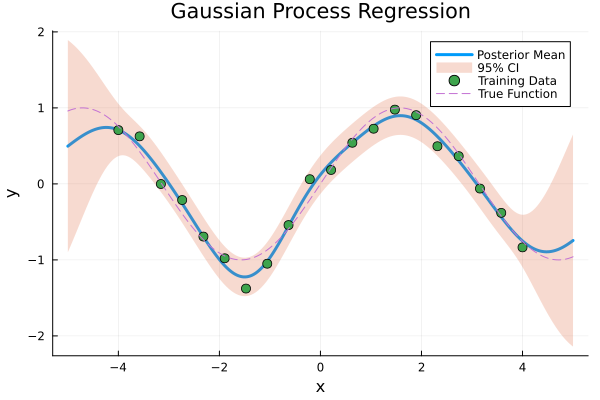

In [18]:
#-------------------------
# Visualization
# -------------------------
plot(
    X_test,
    μ,
    label="Posterior Mean",
    lw=3
)

plot!(
    X_test,
    μ .+ 1.96 .* std,
    fillrange=μ .- 1.96 .* std,
    fillalpha=0.25,
    linealpha=0,
    label="95% CI"
)

scatter!(
    X_train,
    y_train,
    label="Training Data",
    ms=5
)

plot!(
    X_test,
    sin.(X_test),
    ls=:dash,
    label="True Function"
)

xlabel!("x")
ylabel!("y")
title!("Gaussian Process Regression")